# CIFAR-100 Training: ViT-Small vs ResNet18Small

⚠️ 중요: 모든 변수가 정상적으로 초기화되도록 반드시 처음부터 끝까지 (Cell 1 → Cell N) 모든 셀을 순서대로 실행하세요.

이 노트북은 **CIFAR-100 데이터셋(100 클래스)**을 사용하여 ViT-Small과 ResNet18Small 모델을 학습시키고, 두 모델의 성능을 비교합니다.

## 1. Library Import

Make sure to execute cells in order from top to bottom.

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

## 2. 하이퍼파라미터 설정

In [26]:
# 학습 설정
BATCH_SIZE = 64  # 로컬 CPU에서 빠른 학습을 위해 줄임
NUM_EPOCHS = 20  # 빠른 실험을 위해 20 에포크로 설정
LEARNING_RATE = 1e-3  # 짧은 학습을 위해 learning rate 증가
IMAGE_SIZE = 32
PATCH_SIZE = 4
NUM_CLASSES = 100

# 디바이스 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# CIFAR-100 정규화 값
MEAN = (0.5071, 0.4867, 0.4408)
STD = (0.2675, 0.2565, 0.2761)

Using device: cuda


## 3. 데이터셋 준비

### data augmentation(TODO)

In [27]:
# 데이터 변환 정의
transform_train = transforms.Compose([
    #TODO: implement data augmentation
    transforms.RandomCrop(IMAGE_SIZE, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),


    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [28]:


# 데이터셋 로드
print('==> Preparing data..')
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=0)

# CIFAR-100 has 100 classes
print(f'Training samples: {len(trainset)}, Test samples: {len(testset)}')

==> Preparing data..
Training samples: 50000, Test samples: 10000


### 3.1 데이터셋 예시 시각화

==> 데이터셋 샘플 시각화...


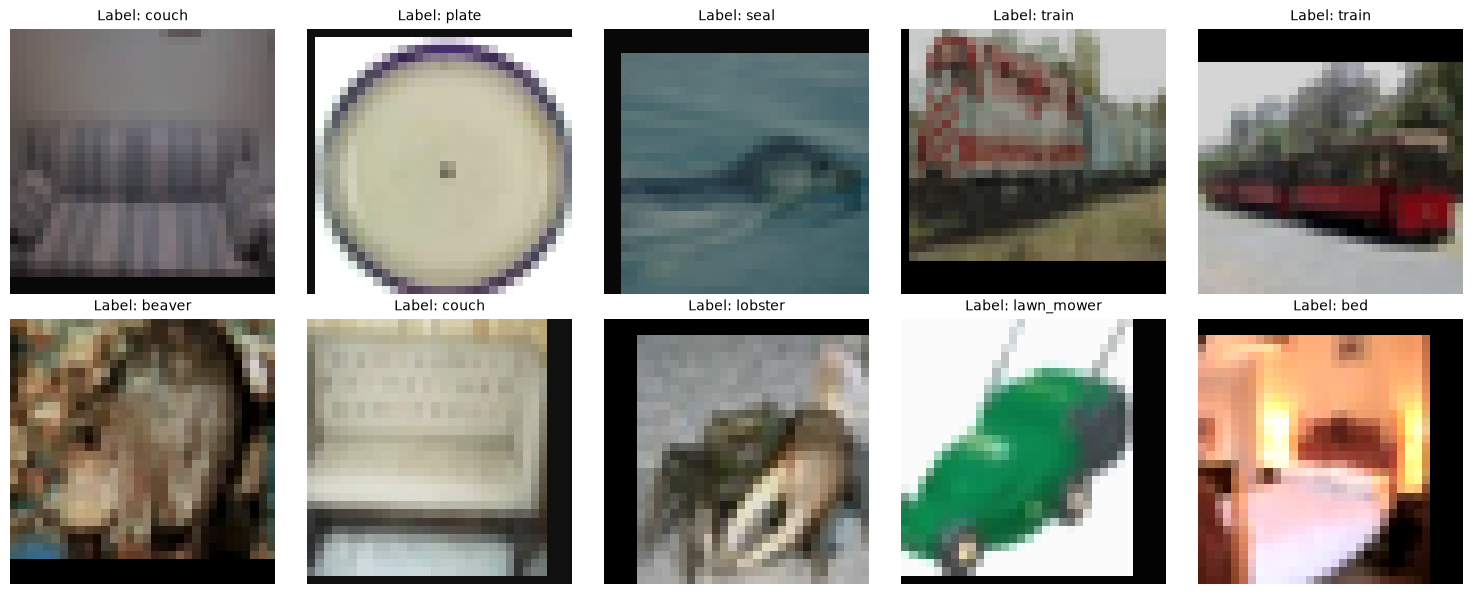


==> 데이터셋 샘플이 dataset_samples.png로 저장되었습니다.


In [29]:
def denormalize(tensor, mean, std):
    """
    정규화된 텐서를 원본 이미지로 복원하는 함수
    
    Args:
        tensor: 정규화된 이미지 텐서 (C, H, W)
        mean: 정규화에 사용된 평균값
        std: 정규화에 사용된 표준편차
        
    Returns:
        원본 범위 [0, 1]로 복원된 텐서
    """
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor


def show_dataset_samples(dataset, classes, mean, std, num_samples=10):
    """
    데이터셋에서 무작위 샘플을 시각화하는 함수
    
    Args:
        dataset: 시각화할 데이터셋
        classes: 클래스 이름 리스트
        mean: 정규화 평균값
        std: 정규화 표준편차
        num_samples: 표시할 샘플 개수
    """
    # 무작위로 샘플 선택
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    # 그리드 설정 (2행 5열)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    
    for idx, sample_idx in enumerate(indices):
        img, label = dataset[sample_idx]
        
        # 정규화 해제
        img = denormalize(img, mean, std)
        
        # 텐서를 numpy로 변환 (C, H, W) -> (H, W, C)
        img = img.permute(1, 2, 0).numpy()
        
        # [0, 1] 범위로 클리핑
        img = np.clip(img, 0, 1)
        
        # 이미지 표시
        axes[idx].imshow(img)
        axes[idx].set_title(f'Label: {classes[label]}', fontsize=10)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n==> 데이터셋 샘플이 dataset_samples.png로 저장되었습니다.')


# 데이터셋 샘플 시각화
print('==> 데이터셋 샘플 시각화...')
show_dataset_samples(trainset, trainset.classes, MEAN, STD, num_samples=10)

### 3.2 데이터 증강 (Augmentation) 효과 시각화

==> 데이터 증강 효과 시각화...


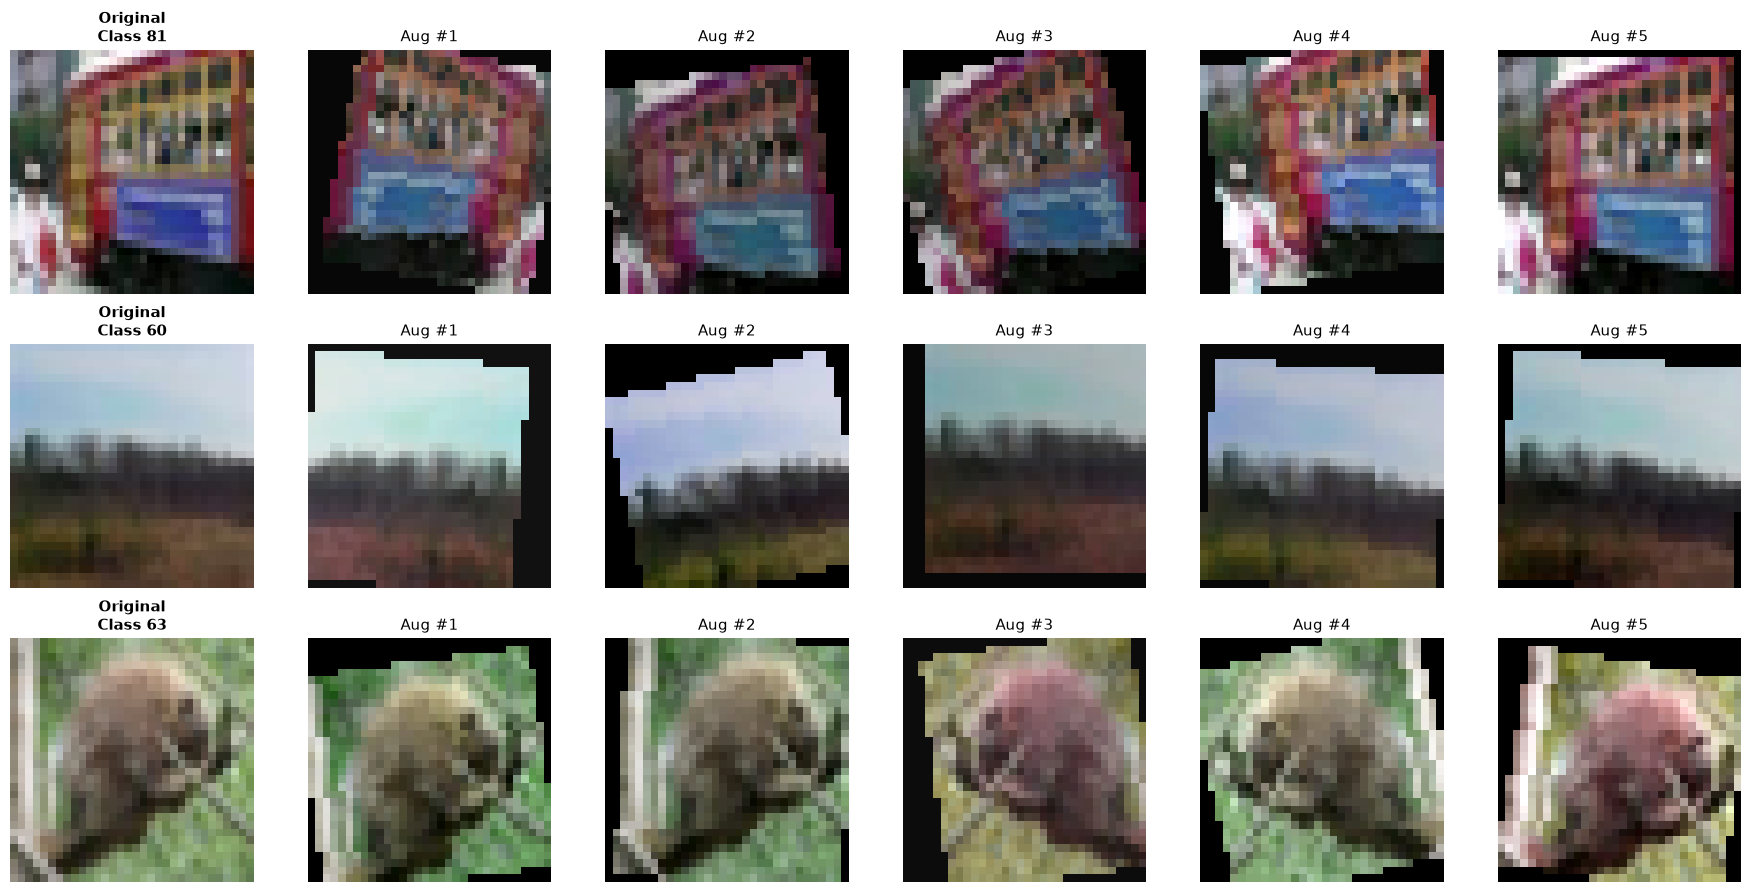

In [30]:
def show_augmentation_examples(num_samples=3, augmentations_per_image=5):
    """
    데이터 증강 효과를 시각화하는 함수
    
    원본 이미지 하나당 여러 번 증강을 적용하여 어떻게 변하는지 보여줍니다.
    
    Args:
        num_samples: 시각화할 원본 이미지 개수
        augmentations_per_image: 각 이미지당 생성할 증강 샘플 개수
    """
    # 증강 없는 데이터셋 (비교용)
    dataset_no_aug = torchvision.datasets.CIFAR100(
        root='./data', train=True, download=False,
        transform=transforms.ToTensor()
    )
    
    # 증강 있는 변환 (정규화 제외)
    transform_aug_viz = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
    ])
    
    # 무작위로 이미지 선택
    indices = np.random.choice(len(dataset_no_aug), num_samples, replace=False)
    
    # 그리드 설정 (각 행: 원본 1개 + 증강 N개)
    fig, axes = plt.subplots(num_samples, augmentations_per_image + 1, 
                            figsize=(3 * (augmentations_per_image + 1), 3 * num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for row, img_idx in enumerate(indices):
        # 원본 이미지 가져오기
        original_img, label = dataset_no_aug[img_idx]
        
        # 원본 이미지 표시
        original_np = original_img.permute(1, 2, 0).numpy()
        axes[row, 0].imshow(original_np)
        axes[row, 0].set_title(f'Original\nClass {label}', fontsize=11, fontweight='bold')
        axes[row, 0].axis('off')
        
        # 증강된 이미지들 표시
        # PIL 이미지로 변환 (transform 적용을 위해)
        from PIL import Image
        pil_img = Image.fromarray((original_np * 255).astype(np.uint8))
        
        for col in range(augmentations_per_image):
            # 증강 적용
            aug_img = transform_aug_viz(pil_img)
            aug_np = aug_img.permute(1, 2, 0).numpy()
            
            # 증강된 이미지 표시
            axes[row, col + 1].imshow(aug_np)
            axes[row, col + 1].set_title(f'Aug #{col+1}', fontsize=11)
            axes[row, col + 1].axis('off')
    
    plt.tight_layout()
    plt.show()


# 데이터 증강 효과 시각화
print('==> 데이터 증강 효과 시각화...')
show_augmentation_examples(num_samples=3, augmentations_per_image=5)

## 4. 모델 정의

### 4.1 ResNet18Small 모델

In [31]:
class BasicBlock(nn.Module):
    """
    ResNet의 기본 빌딩 블록 (BasicBlock)
    
    ResNet18과 ResNet34에서 사용되는 residual block입니다.
    두 개의 3x3 convolution layer로 구성되며, skip connection을 통해
    입력을 출력에 더해주는 구조입니다.
    
    구조:
        Input
          ├─→ Conv(3×3) → BN → ReLU → Conv(3×3) → BN ─→ +
          └────────────────────────────────────────────→ ↓
                                                      ReLU → Output
    
    Args:
        in_planes (int): 입력 채널 수
        planes (int): 출력 채널 수 (첫 번째 conv의 출력 채널)
        stride (int): stride 크기. 2일 경우 feature map 크기가 절반으로 줄어듦
    """
    expansion = 1  # BasicBlock은 채널 수 확장이 없음 (Bottleneck과 구분)

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        
        # TODO 1) conv1, bn1 정의
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        # TODO 2) conv2, bn2 정의
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        # TODO 3) shortcut 정의
        # Shortcut connection (skip connection)
        # 입력과 출력의 차원이 다를 경우 1x1 conv로 차원 맞춤
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: 입력 텐서 (batch_size, in_planes, H, W)
            
        Returns:
            출력 텐서 (batch_size, planes, H', W')
            H', W'는 stride에 따라 결정됨
        """
        # TODO 4) main path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # TODO 5) skip connection
        out = out + self.shortcut(x)

        # TODO 6) 마지막 ReLU
        out = F.relu(out)
        
        return out


class ResNetSmall(nn.Module):
    """
    경량화된 ResNet18 모델 (ResNet18Small)
    
    원본 ResNet18의 채널 수를 약 37.5%로 줄여 파라미터 수를 
    11.17M에서 1.58M으로 대폭 감소시킨 모델입니다.
    
    채널 구조 비교:
        ResNet18:      64 → 64  → 128 → 256 → 512
        ResNet18Small: 24 → 24  → 48  → 96  → 192
    
    구조:
        Input (32×32×3)
          ↓
        Conv1 (3×3, 24 channels)
          ↓
        Layer1: 2× BasicBlock (24 channels, stride=1)  → 32×32
          ↓
        Layer2: 2× BasicBlock (48 channels, stride=2)  → 16×16
          ↓
        Layer3: 2× BasicBlock (96 channels, stride=2)  → 8×8
          ↓
        Layer4: 2× BasicBlock (192 channels, stride=2) → 4×4
          ↓
        AvgPool (4×4) → FC (192 → num_classes)
    
    Args:
        block: 사용할 블록 타입 (BasicBlock 또는 Bottleneck)
        num_blocks: 각 layer의 블록 개수 리스트 [2,2,2,2]
        num_classes: 분류할 클래스 개수 (CIFAR-10: 10, CIFAR-100: 100)
    """
    
    def __init__(self, block, num_blocks, num_classes=100):
        super(ResNetSmall, self).__init__()
        self.in_planes = 24  # 초기 채널 수 (원본 ResNet18의 64에서 24로 축소)

        # 첫 번째 convolution layer
        self.conv1 = nn.Conv2d(3, 24, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(24)
        
        # 4개의 residual layer 생성
        self.layer1 = self._make_layer(block, 24, num_blocks[0], stride=1)   # 32×32 유지
        self.layer2 = self._make_layer(block, 48, num_blocks[1], stride=2)   # 16×16
        self.layer3 = self._make_layer(block, 96, num_blocks[2], stride=2)   # 8×8
        self.layer4 = self._make_layer(block, 192, num_blocks[3], stride=2)  # 4×4
        
        # 최종 classification layer
        self.linear = nn.Linear(192 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        """
        Residual layer를 생성하는 헬퍼 함수
        
        각 layer는 여러 개의 residual block으로 구성됩니다.
        첫 번째 블록에서만 stride를 적용하여 downsampling하고,
        나머지 블록들은 stride=1로 feature map 크기를 유지합니다.
        
        Args:
            block: 블록 타입 (BasicBlock)
            planes: 출력 채널 수
            num_blocks: 이 layer에 포함될 블록 개수
            stride: 첫 번째 블록의 stride (downsampling 여부 결정)
            
        Returns:
            nn.Sequential: 여러 블록이 순차적으로 연결된 layer
        """
        strides = [stride] + [1] * (num_blocks - 1)  # [stride, 1, 1, ...]
        layers = []
        
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion  # 다음 블록의 입력 채널 수 업데이트
            
        return nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: 입력 이미지 텐서 (batch_size, 3, 32, 32)
            
        Returns:
            출력 로짓 (batch_size, num_classes)
        """
        # Initial convolution
        out = F.relu(self.bn1(self.conv1(x)))  # (B, 24, 32, 32)
        
        # 4개의 residual layer 통과
        out = self.layer1(out)  # (B, 24, 32, 32)
        out = self.layer2(out)  # (B, 48, 16, 16)
        out = self.layer3(out)  # (B, 96, 8, 8)
        out = self.layer4(out)  # (B, 192, 4, 4)
        
        # Global average pooling
        out = F.avg_pool2d(out, 4)  # (B, 192, 1, 1)
        
        # Flatten
        out = out.view(out.size(0), -1)  # (B, 192)
        
        # Classification
        out = self.linear(out)  # (B, num_classes)
        
        return out


def ResNet18Small(num_classes=10):
    """
    ResNet18Small 모델 생성 함수
    
    Args:
        num_classes: 분류할 클래스 개수
        
    Returns:
        ResNet18Small 모델 (파라미터: ~1.58M)
    """
    return ResNetSmall(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)

### 4.2 ViT-Small 모델

In [32]:
def pair(t):
    """
    단일 값을 튜플로 변환하는 헬퍼 함수
    
    이미 튜플이면 그대로 반환하고, 아니면 (t, t) 형태로 변환합니다.
    주로 image_size, patch_size 등을 처리할 때 사용합니다.
    
    Args:
        t: 정수 또는 튜플
        
    Returns:
        튜플 (t, t) 또는 원본 튜플
    """
    return t if isinstance(t, tuple) else (t, t)


class PreNorm(nn.Module):
    """
    LayerNorm을 먼저 적용한 후 함수를 실행하는 래퍼 클래스
    
    Transformer의 Pre-LayerNorm 구조를 구현합니다.
    일반적으로 Attention이나 FeedForward 전에 정규화를 수행합니다.
    
    Args:
        dim: 입력 차원
        fn: 적용할 함수 (Attention 또는 FeedForward)
    """
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn
        
    def forward(self, x, **kwargs):
        """정규화 후 함수 적용"""
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    """
    Transformer의 Feed-Forward Network (FFN)
    
    Position-wise fully connected feed-forward network입니다.
    두 개의 linear layer와 GELU 활성화 함수로 구성됩니다.
    
    구조:
        Input → Linear(dim → hidden_dim) → GELU → Dropout 
              → Linear(hidden_dim → dim) → Dropout → Output
    
    Args:
        dim: 입력/출력 차원
        hidden_dim: 은닉층 차원 (일반적으로 dim의 4배)
        dropout: 드롭아웃 비율
    """
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
        
    def forward(self, x):
        """FFN 적용"""
        return self.net(x)


class LSA(nn.Module):
    """
    Locality Self-Attention (LSA)
    
    일반적인 self-attention과 달리 자기 자신에 대한 attention을 mask하여
    지역적 정보(locality)를 강조하는 attention mechanism입니다.
    
    특징:
        - 자기 자신을 보지 못하도록 대각선 mask 적용
        - 온도 파라미터(temperature)를 학습 가능하게 설정
        - Multi-head attention 구조
    
    Args:
        dim: 입력 차원
        heads: attention head 개수
        dim_head: 각 head의 차원
        dropout: 드롭아웃 비율
    """
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.):
        super().__init__()
        inner_dim = dim_head * heads
        self.heads = heads
        
        # 학습 가능한 temperature 파라미터 (스케일링 팩터)
        self.temperature = nn.Parameter(torch.log(torch.tensor(dim_head ** -0.5)))
        
        self.attend = nn.Softmax(dim=-1)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)
        
        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        """
        LSA forward pass
        
        Args:
            x: 입력 텐서 (batch, num_patches, dim)
            
        Returns:
            attention 적용된 출력 (batch, num_patches, dim)
        """
        # Q, K, V 생성
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.heads), qkv)
        
        # Attention score 계산: Q @ K^T * temperature
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.temperature.exp()
        
        # 자기 자신에 대한 attention mask (대각선)
        mask = torch.eye(dots.shape[-1], device=dots.device, dtype=torch.bool)
        mask_value = -torch.finfo(dots.dtype).max
        dots = dots.masked_fill(mask, mask_value)
        
        # Softmax로 attention weights 계산
        attn = self.attend(dots)
        
        # Attention 적용: weights @ V
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        
        return self.to_out(out)


class Transformer(nn.Module):
    """
    Transformer Encoder
    
    여러 개의 Transformer block을 쌓아 구성합니다.
    각 block은 LSA + FFN으로 구성되며, residual connection이 적용됩니다.
    
    구조 (각 block마다):
        Input → PreNorm → LSA ─┬→ + → PreNorm → FFN ─┬→ + → Output
          └──────────────────┘              └──────────┘
          (residual connection)           (residual connection)
    
    Args:
        dim: 입력/출력 차원
        depth: Transformer block 개수
        heads: attention head 개수
        dim_head: 각 head의 차원
        mlp_dim: FFN의 은닉층 차원
        dropout: 드롭아웃 비율
    """
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        
        # depth 만큼 Transformer block 생성
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, LSA(dim, heads=heads, dim_head=dim_head, dropout=dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout=dropout))
            ]))
            
    def forward(self, x):
        """
        Transformer forward pass
        
        Args:
            x: 입력 텐서 (batch, num_patches+1, dim)
            
        Returns:
            변환된 출력 (batch, num_patches+1, dim)
        """
        # 각 Transformer block 통과
        for attn, ff in self.layers:
            x = attn(x) + x  # Attention + residual
            x = ff(x) + x    # FFN + residual
            
        return x


class SPT(nn.Module):
    """
    Shifted Patch Tokenization (SPT)
    
    일반적인 patch embedding과 달리, 원본 이미지와 shifted된 이미지들을
    함께 사용하여 더 풍부한 patch representation을 생성합니다.
    
    동작 방식:
        1. 원본 이미지 + 상하좌우로 1픽셀 shifted된 4개 이미지 = 총 5개
        2. 각각을 patch로 분할 (채널 방향으로 concatenate)
        3. Linear projection으로 embedding 차원으로 변환
    
    Args:
        dim: 출력 embedding 차원
        patch_size: 패치 크기
        channels: 입력 이미지 채널 수 (RGB: 3)
    """
    def __init__(self, *, dim, patch_size, channels=3):
        super().__init__()
        # 5개 이미지 (원본 + shifted 4개) × channels
        patch_dim = patch_size * patch_size * 5 * channels
        
        self.to_patch_tokens = nn.Sequential(
            # 이미지를 패치로 분할
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', 
                     p1=patch_size, p2=patch_size),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim)
        )

    def forward(self, x):
        """
        SPT forward pass
        
        Args:
            x: 입력 이미지 (batch, 3, H, W)
            
        Returns:
            패치 임베딩 (batch, num_patches, dim)
        """
        # 상하좌우로 1픽셀 shift (padding으로 구현)
        shifts = ((1, -1, 0, 0), (-1, 1, 0, 0), (0, 0, 1, -1), (0, 0, -1, 1))
        shifted_x = list(map(lambda shift: F.pad(x, shift), shifts))
        
        # 원본 + shifted 4개 = 5개를 채널 방향으로 concat
        x_with_shifts = torch.cat((x, *shifted_x), dim=1)  # (B, 15, H, W)
        
        # 패치로 변환 및 embedding
        return self.to_patch_tokens(x_with_shifts)


class ViT(nn.Module):
    """
    Vision Transformer (ViT) with Shifted Patch Tokenization
    
    이미지 분류를 위한 Transformer 모델입니다.
    SPT를 사용하여 이미지를 패치로 변환하고, Transformer encoder로 처리한 뒤
    classification head로 최종 예측을 수행합니다.
    
    전체 구조:
        Input Image (32×32×3)
          ↓
        SPT (Shifted Patch Tokenization)
          ↓
        Patch Embeddings (64 patches × dim)
          ↓
        + CLS Token + Positional Embedding
          ↓
        Dropout
          ↓
        Transformer Encoder (depth layers)
          ↓
        CLS Token 추출 (또는 mean pooling)
          ↓
        MLP Head (LayerNorm → Linear)
          ↓
        Classification Output (num_classes)
    
    Args:
        image_size: 입력 이미지 크기 (정사각형)
        patch_size: 패치 크기
        num_classes: 분류할 클래스 개수
        dim: embedding 차원
        depth: Transformer block 개수
        heads: attention head 개수
        mlp_dim: FFN 은닉층 차원
        pool: pooling 방식 ('cls' 또는 'mean')
        channels: 입력 이미지 채널 수
        dim_head: 각 attention head의 차원
        dropout: attention/FFN dropout 비율
        emb_dropout: embedding dropout 비율
    """
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, 
                 mlp_dim, pool='cls', channels=3, dim_head=64, dropout=0., emb_dropout=0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)
        
        # 이미지가 패치 크기로 나누어떨어지는지 확인
        assert image_height % patch_height == 0 and image_width % patch_width == 0, \
            'Image dimensions must be divisible by the patch size.'
        
        # 패치 개수 계산
        num_patches = (image_height // patch_height) * (image_width // patch_width)
        
        assert pool in {'cls', 'mean'}, 'pool type must be either cls or mean'
        
        # TODO 1) patch embedding
        self.to_patch_embedding = SPT(dim=dim, patch_size=patch_size, channels=channels)

        # TODO 2) cls token, positional embedding
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        # TODO 3) dropout, transformer, head
        self.dropout = nn.Dropout(emb_dropout)
        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)
        self.pool = pool
        self.to_latent = nn.Identity()
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        """
        ViT forward pass
        
        Args:
            img: 입력 이미지 (batch, 3, H, W)
            
        Returns:
            분류 로짓 (batch, num_classes)
        """
        # TODO 5) patch embedding
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        # TODO 6) cls token concat
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)

        # TODO 7) pos embedding + dropout
        x = x + self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        # TODO 8) transformer
        x = self.transformer(x)

        # TODO 9) pooling
        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]

        # TODO 10) classification head
        x = self.to_latent(x)
        return self.mlp_head(x)

def create_vit_small():
    """
    ViT-Small 모델 생성 함수
    
    경량화된 ViT 모델로, 다음과 같은 설정을 사용합니다:
        - Embedding dim: 256 (표준 ViT의 768에서 축소)
        - Depth: 4 layers (표준 ViT의 12에서 축소)
        - Heads: 4 (표준 ViT의 12에서 축소)
        - MLP dim: 256 (표준 ViT의 3072에서 축소)
    
    Returns:
        ViT 모델 (파라미터: ~1.66M)
    """
    model = ViT(
        image_size=IMAGE_SIZE,      # 32
        patch_size=PATCH_SIZE,       # 4
        num_classes=NUM_CLASSES,     # 100
        dim=256,                      # Embedding 차원
        depth=4,                      # Transformer layers
        heads=4,                      # Attention heads
        mlp_dim=256,                  # FFN hidden dim
        dropout=0.1,
        emb_dropout=0.1
    )
    return model


def create_resnet18_small():
    """
    ResNet18Small 모델 생성 함수
    
    Returns:
        ResNet18Small 모델 (파라미터: ~1.58M)
    """
    model = ResNet18Small(num_classes=NUM_CLASSES)
    return model

## 5. 학습 및 평가 함수

In [33]:
def train_epoch(model, trainloader, criterion, optimizer, device):
    """한 에포크 학습"""
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(trainloader, desc='Training')
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        pbar.set_postfix({'loss': train_loss/(pbar.n+1), 'acc': 100.*correct/total})
    
    return train_loss/len(trainloader), 100.*correct/total

def evaluate(model, testloader, criterion, device):
    """모델 평가"""
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(testloader, desc='Testing')
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            pbar.set_postfix({'loss': test_loss/(pbar.n+1), 'acc': 100.*correct/total})
    
    return test_loss/len(testloader), 100.*correct/total

## 6. 전체 학습 함수

In [34]:
def train_model(model, model_name, num_epochs=NUM_EPOCHS):
    """모델 학습 전체 프로세스"""
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)
    
    # 기록용
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'lr': []
    }
    
    best_acc = 0
    
    print(f'\n==> Training {model_name}...')
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f'\nEpoch: {epoch+1}/{num_epochs}')
        
        # 학습
        train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, device)
        
        # 평가
        test_loss, test_acc = evaluate(model, testloader, criterion, device)
        
        # 스케줄러 업데이트
        scheduler.step()
        
        # 기록
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # 결과 출력
        print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}%')
        print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc:.2f}%')
        print(f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
        # 베스트 모델 저장
        if test_acc > best_acc:
            best_acc = test_acc
            print(f'==> Saving best model.. (Acc: {best_acc:.2f}%)')
    
    total_time = time.time() - start_time
    print(f'\nTraining completed in {total_time/60:.2f} minutes')
    print(f'Best Test Accuracy: {best_acc:.2f}%')
    
    return history, best_acc

## 7. ViT-Small 학습

In [35]:
# ViT-Small 모델 생성 및 학습
vit_model = create_vit_small()
print(f'ViT-Small Parameters: {sum(p.numel() for p in vit_model.parameters())/1e6:.2f}M')

vit_history, vit_best_acc = train_model(vit_model, 'ViT-Small', num_epochs=NUM_EPOCHS)

ViT-Small Parameters: 1.69M

==> Training ViT-Small...

Epoch: 1/20


Testing: 100%|██████████| 100/100 [00:03<00:00, 30.46it/s, loss=3.7, acc=14.9]


Train Loss: 3.958 | Train Acc: 9.24%
Test Loss: 3.588 | Test Acc: 14.90%
LR: 0.000994
==> Saving best model.. (Acc: 14.90%)

Epoch: 2/20


Testing: 100%|██████████| 100/100 [00:03<00:00, 31.11it/s, loss=3.24, acc=21.2]


Train Loss: 3.457 | Train Acc: 16.80%
Test Loss: 3.203 | Test Acc: 21.17%
LR: 0.000976
==> Saving best model.. (Acc: 21.17%)

Epoch: 3/20


...

Train Loss: 1.893 | Train Acc: 48.36%
Test Loss: 1.988 | Test Acc: 47.16%
LR: 0.000024

Epoch: 19/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 23.25it/s, loss=2.02, acc=47.4]


Train Loss: 1.867 | Train Acc: 49.04%
Test Loss: 1.980 | Test Acc: 47.43%
LR: 0.000006
==> Saving best model.. (Acc: 47.43%)

Epoch: 20/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 22.99it/s, loss=1.98, acc=47.4]

Train Loss: 1.862 | Train Acc: 48.92%
Test Loss: 1.979 | Test Acc: 47.44%
LR: 0.000000
==> Saving best model.. (Acc: 47.44%)

Training completed in 22.68 minutes
Best Test Accuracy: 47.44%


## 8. ResNet18Small 학습

In [36]:
# ResNet18Small 모델 생성 및 학습
resnet_model = create_resnet18_small()
print(f'ResNet18Small Parameters: {sum(p.numel() for p in resnet_model.parameters())/1e6:.2f}M')

resnet_history, resnet_best_acc = train_model(resnet_model, 'ResNet18Small', num_epochs=NUM_EPOCHS)

ResNet18Small Parameters: 1.59M

==> Training ResNet18Small...

Epoch: 1/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 23.86it/s, loss=3.45, acc=17.7]


Train Loss: 3.800 | Train Acc: 11.08%
Test Loss: 3.385 | Test Acc: 17.71%
LR: 0.000994
==> Saving best model.. (Acc: 17.71%)

Epoch: 2/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 24.03it/s, loss=2.75, acc=30.6]


Train Loss: 3.065 | Train Acc: 23.32%
Test Loss: 2.694 | Test Acc: 30.62%
LR: 0.000976
==> Saving best model.. (Acc: 30.62%)

Epoch: 3/20


...

Train Loss: 0.896 | Train Acc: 73.36%
Test Loss: 1.292 | Test Acc: 63.82%
LR: 0.000024
==> Saving best model.. (Acc: 63.82%)

Epoch: 19/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 24.68it/s, loss=1.3, acc=64.1]


Train Loss: 0.877 | Train Acc: 74.13%
Test Loss: 1.291 | Test Acc: 64.14%
LR: 0.000006
==> Saving best model.. (Acc: 64.14%)

Epoch: 20/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 21.16it/s, loss=1.31, acc=64.1]

Train Loss: 0.867 | Train Acc: 74.29%
Test Loss: 1.287 | Test Acc: 64.07%
LR: 0.000000

Training completed in 27.20 minutes
Best Test Accuracy: 64.14%


In [37]:
def count_parameters(model):
    """
    모델의 총 파라미터 수를 계산
    
    Args:
        model: PyTorch 모델
        
    Returns:
        파라미터 수 (정수)
    """
    return sum(p.numel() for p in model.parameters())


def calculate_flops_vit(model, image_size=32, patch_size=4):
    """
    ViT 모델의 FLOPs 계산 (근사값)
    
    Args:
        model: ViT 모델
        image_size: 입력 이미지 크기
        patch_size: 패치 크기
        
    Returns:
        FLOPs (부동소수점 연산 횟수)
    """
    num_patches = (image_size // patch_size) ** 2
    
    # Patch embedding: SPT 사용 (5개 이미지 concat)
    patch_dim = patch_size * patch_size * 3 * 5
    embed_dim = model.to_patch_embedding.to_patch_tokens[-1].out_features
    embedding_flops = num_patches * patch_dim * embed_dim
    
    # Transformer blocks
    depth = len(model.transformer.layers)
    seq_len = num_patches + 1  # +1 for CLS token
    
    # Self-attention per block
    # Q, K, V projection: 3 * seq_len * embed_dim * embed_dim
    # Attention: seq_len * seq_len * embed_dim
    # Output projection: seq_len * embed_dim * embed_dim
    attn_flops_per_block = (
        3 * seq_len * embed_dim * embed_dim +  # QKV projection
        seq_len * seq_len * embed_dim +         # Attention computation
        seq_len * embed_dim * embed_dim         # Output projection
    )
    
    # FFN per block
    # Linear1: seq_len * embed_dim * mlp_dim
    # Linear2: seq_len * mlp_dim * embed_dim
    mlp_dim = model.transformer.layers[0][1].fn.net[0].out_features
    ffn_flops_per_block = (
        seq_len * embed_dim * mlp_dim +
        seq_len * mlp_dim * embed_dim
    )
    
    transformer_flops = depth * (attn_flops_per_block + ffn_flops_per_block)
    
    # Classification head
    head_flops = embed_dim * model.mlp_head[-1].out_features
    
    total_flops = embedding_flops + transformer_flops + head_flops
    return total_flops


def calculate_flops_resnet(model, image_size=32):
    """
    ResNet 모델의 FLOPs 계산 (근사값)
    
    Args:
        model: ResNet 모델
        image_size: 입력 이미지 크기
        
    Returns:
        FLOPs (부동소수점 연산 횟수)
    """
    def conv_flops(in_channels, out_channels, kernel_size, h, w, stride=1):
        """Convolution FLOPs 계산"""
        out_h = h // stride
        out_w = w // stride
        return kernel_size * kernel_size * in_channels * out_channels * out_h * out_w
    
    flops = 0
    h, w = image_size, image_size
    
    # Initial conv: 3x3, 3->24
    flops += conv_flops(3, 24, 3, h, w)
    
    # Layer1: 2 blocks, 24->24, stride=1
    for _ in range(2):
        flops += conv_flops(24, 24, 3, h, w)  # conv1
        flops += conv_flops(24, 24, 3, h, w)  # conv2
    
    # Layer2: 2 blocks, 24->48, stride=2 (first), then 48->48
    h, w = h // 2, w // 2
    flops += conv_flops(24, 48, 3, h*2, w*2, stride=2)  # first conv1
    flops += conv_flops(48, 48, 3, h, w)  # first conv2
    flops += conv_flops(24, 48, 1, h*2, w*2, stride=2)  # shortcut
    flops += conv_flops(48, 48, 3, h, w)  # second conv1
    flops += conv_flops(48, 48, 3, h, w)  # second conv2
    
    # Layer3: 2 blocks, 48->96, stride=2 (first), then 96->96
    h, w = h // 2, w // 2
    flops += conv_flops(48, 96, 3, h*2, w*2, stride=2)  # first conv1
    flops += conv_flops(96, 96, 3, h, w)  # first conv2
    flops += conv_flops(48, 96, 1, h*2, w*2, stride=2)  # shortcut
    flops += conv_flops(96, 96, 3, h, w)  # second conv1
    flops += conv_flops(96, 96, 3, h, w)  # second conv2
    
    # Layer4: 2 blocks, 96->192, stride=2 (first), then 192->192
    h, w = h // 2, w // 2
    flops += conv_flops(96, 192, 3, h*2, w*2, stride=2)  # first conv1
    flops += conv_flops(192, 192, 3, h, w)  # first conv2
    flops += conv_flops(96, 192, 1, h*2, w*2, stride=2)  # shortcut
    flops += conv_flops(192, 192, 3, h, w)  # second conv1
    flops += conv_flops(192, 192, 3, h, w)  # second conv2
    
    # FC layer
    flops += 192 * model.linear.out_features
    
    return flops


# 모델 효율성 지표 계산
print('==> 모델 효율성 지표 계산 중...\n')

models_info = []

# ViT-Small
vit_params = count_parameters(vit_model)
vit_flops = calculate_flops_vit(vit_model)
models_info.append({
    'name': 'ViT-Small',
    'type': 'ViT',
    'params': vit_params,
    'flops': vit_flops,
    'accuracy': vit_best_acc,
    'marker': 'o',
    'color': 'blue'
})

# ResNet18Small
resnet_params = count_parameters(resnet_model)
resnet_flops = calculate_flops_resnet(resnet_model)
models_info.append({
    'name': 'ResNet18Small',
    'type': 'CNN',
    'params': resnet_params,
    'flops': resnet_flops,
    'accuracy': resnet_best_acc,
    'marker': 's',
    'color': 'red'
})

# 결과 출력
print('모델 효율성 지표:')
print('='*80)
for model in models_info:
    acc_per_param = model['accuracy'] / model['params']
    acc_per_flop = model['accuracy'] / model['flops']
    
    print(f"\n{model['name']} ({model['type']}):")
    print(f"  - Parameters: {model['params']:,} ({model['params']/1e6:.2f}M)")
    print(f"  - FLOPs: {model['flops']:,} ({model['flops']/1e6:.2f}M)")
    print(f"  - Test Accuracy: {model['accuracy']:.2f}%")
    print(f"  - Accuracy per Param: {acc_per_param:.6e}")
    print(f"  - Accuracy per FLOP:  {acc_per_flop:.6e}")
print('='*80)

==> 모델 효율성 지표 계산 중...

모델 효율성 지표:

ViT-Small (ViT):
  - Parameters: 1,685,320 (1.69M)
  - FLOPs: 110,520,320 (110.52M)
  - Test Accuracy: 47.44%
  - Accuracy per Param: 2.814896e-05
  - Accuracy per FLOP:  4.292423e-07

ResNet18Small (CNN):
  - Parameters: 1,592,572 (1.59M)
  - FLOPs: 78,539,520 (78.54M)
  - Test Accuracy: 64.14%
  - Accuracy per Param: 4.027447e-05
  - Accuracy per FLOP:  8.166589e-07


## 9. 결과 시각화

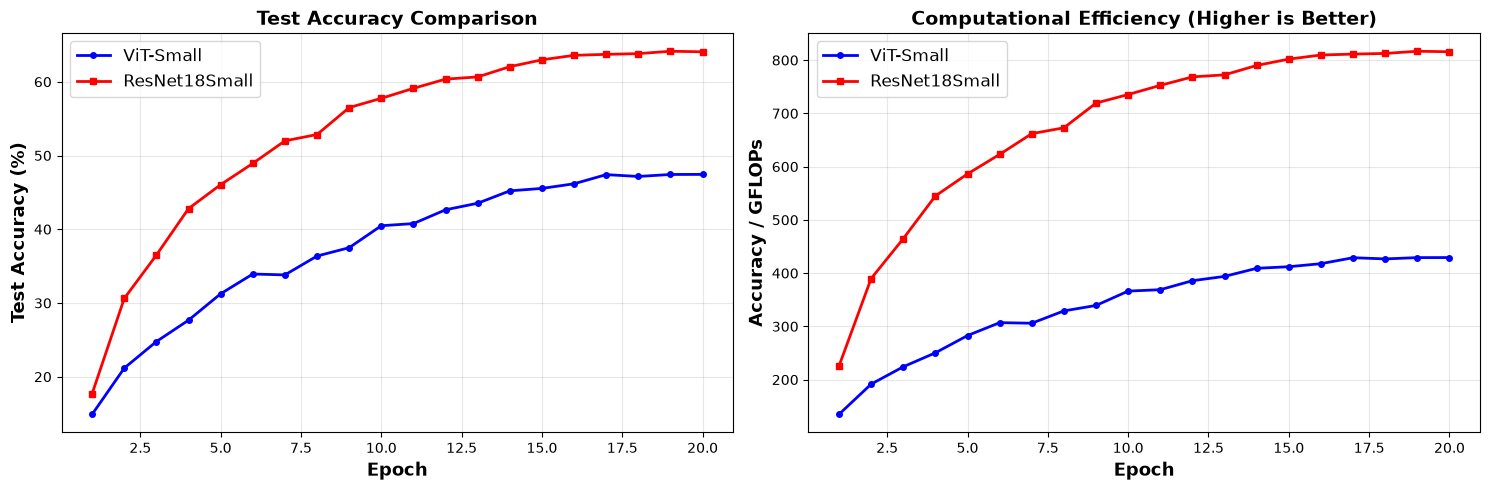


==> Training comparison graph saved as training_comparison.png


In [38]:
# CIFAR-100 학습 결과 그래프
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, NUM_EPOCHS + 1)

# Test Accuracy
axes[0].plot(epochs, vit_history['test_acc'], 'b-', label='ViT-Small', linewidth=2, marker='o', markersize=4)
axes[0].plot(epochs, resnet_history['test_acc'], 'r-', label='ResNet18Small', linewidth=2, marker='s', markersize=4)
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Accuracy per FLOPs (효율성)
vit_flops_per_epoch = vit_flops  # FLOPs per forward pass
resnet_flops_per_epoch = resnet_flops

axes[1].plot(epochs, [acc / (vit_flops_per_epoch / 1e9) for acc in vit_history['test_acc']], 
             'b-', label='ViT-Small', linewidth=2, marker='o', markersize=4)
axes[1].plot(epochs, [acc / (resnet_flops_per_epoch / 1e9) for acc in resnet_history['test_acc']], 
             'r-', label='ResNet18Small', linewidth=2, marker='s', markersize=4)
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy / GFLOPs', fontsize=13, fontweight='bold')
axes[1].set_title('Computational Efficiency (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n==> Training comparison graph saved as training_comparison.png')

## 10. 최종 결과 요약

In [39]:
print('\n' + '='*60)
print('CIFAR-100 Training Results'.center(60))
print('='*60)
print(f'\nViT-Small:')
print(f'  - Parameters: {sum(p.numel() for p in vit_model.parameters())/1e6:.2f}M')
print(f'  - Best Test Accuracy: {vit_best_acc:.2f}%')
print(f'  - Final Train Accuracy: {vit_history["train_acc"][-1]:.2f}%')
print(f'  - Final Test Accuracy: {vit_history["test_acc"][-1]:.2f}%')

print(f'\nResNet18Small:')
print(f'  - Parameters: {sum(p.numel() for p in resnet_model.parameters())/1e6:.2f}M')
print(f'  - Best Test Accuracy: {resnet_best_acc:.2f}%')
print(f'  - Final Train Accuracy: {resnet_history["train_acc"][-1]:.2f}%')
print(f'  - Final Test Accuracy: {resnet_history["test_acc"][-1]:.2f}%')

print('\n' + '='*60)


                 CIFAR-100 Training Results                 

ViT-Small:
  - Parameters: 1.69M
  - Best Test Accuracy: 47.44%
  - Final Train Accuracy: 48.92%
  - Final Test Accuracy: 47.44%

ResNet18Small:
  - Parameters: 1.59M
  - Best Test Accuracy: 64.14%
  - Final Train Accuracy: 74.29%
  - Final Test Accuracy: 64.07%



## 11. 모델 추론 결과 시각화


==> Visualizing model predictions...


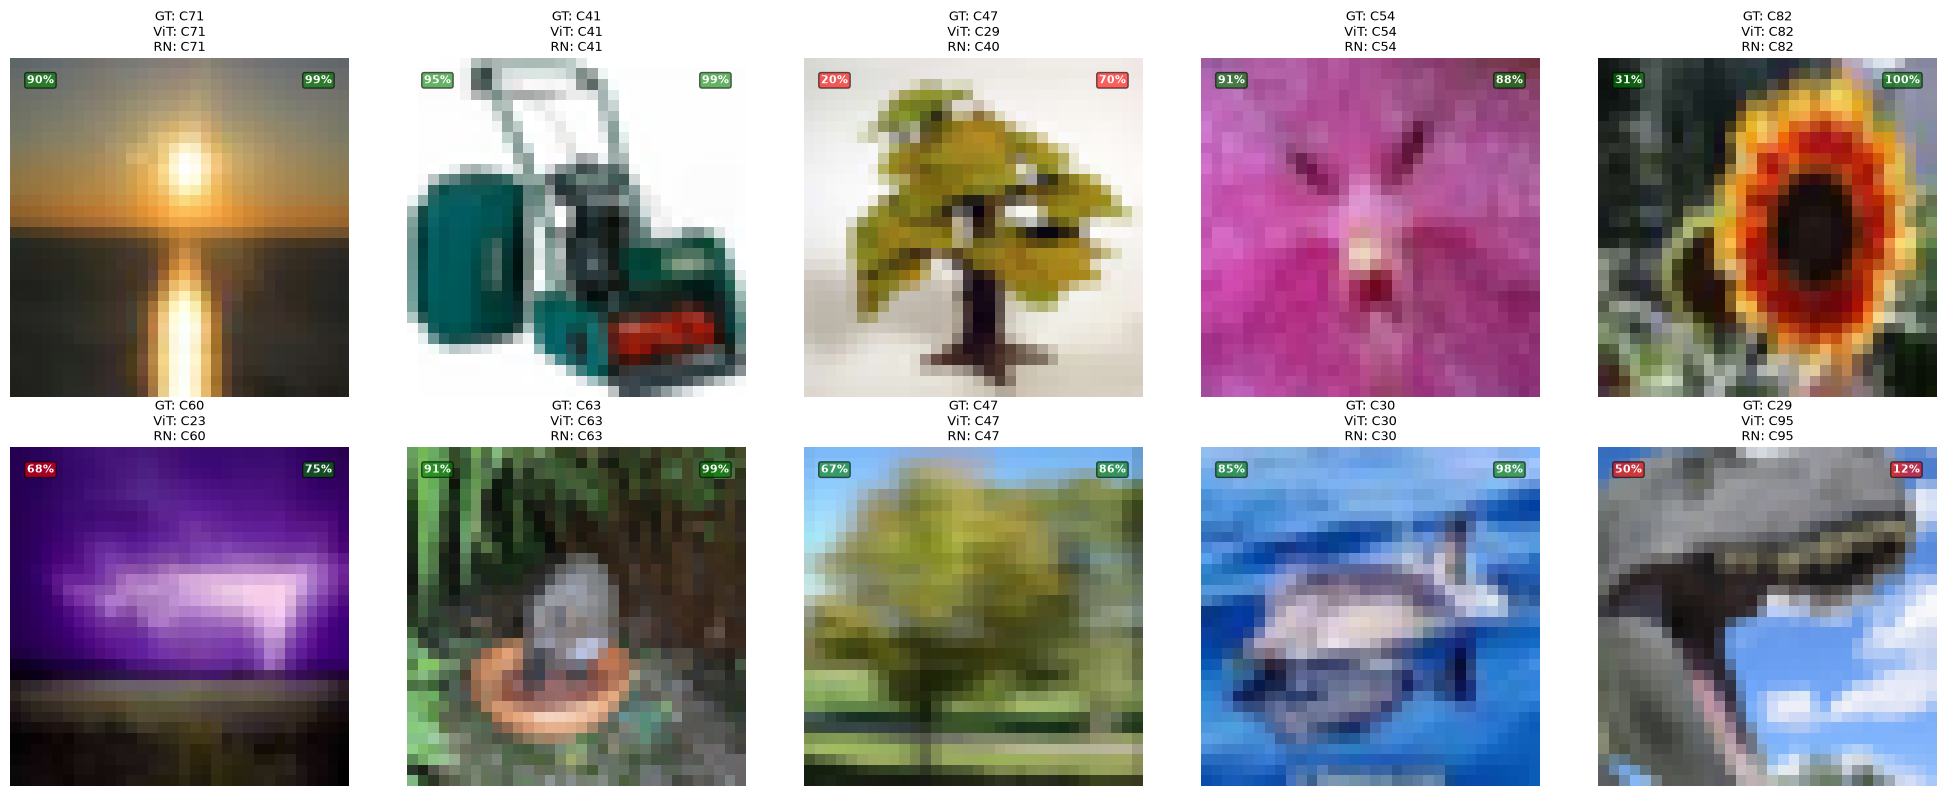


==> Model predictions saved as model_predictions.png


In [40]:
def visualize_predictions(vit_model, resnet_model, testset, classes, mean, std, num_samples=10):
    """Model prediction visualization (2x5 grid)"""
    vit_model.eval()
    resnet_model.eval()
    
    indices = np.random.choice(len(testset), num_samples, replace=False)
    
    # 2x5 grid
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.ravel()
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            img, true_label = testset[sample_idx]
            img_batch = img.unsqueeze(0).to(device)
            
            vit_output = vit_model(img_batch)
            resnet_output = resnet_model(img_batch)
            
            vit_probs = F.softmax(vit_output, dim=1)
            resnet_probs = F.softmax(resnet_output, dim=1)
            
            vit_pred = vit_output.argmax(dim=1).item()
            resnet_pred = resnet_output.argmax(dim=1).item()
            
            vit_conf = vit_probs[0, vit_pred].item() * 100
            resnet_conf = resnet_probs[0, resnet_pred].item() * 100
            
            img_show = denormalize(img, mean, std)
            img_show = img_show.permute(1, 2, 0).numpy()
            img_show = np.clip(img_show, 0, 1)
            
            axes[idx].imshow(img_show)
            axes[idx].axis('off')
            
            # Short class names for CIFAR-100
            if len(classes) > 10:
                true_class = f'C{true_label}'
                vit_class = f'C{vit_pred}'
                resnet_class = f'C{resnet_pred}'
            else:
                true_class = classes[true_label]
                vit_class = classes[vit_pred]
                resnet_class = classes[resnet_pred]
            
            vit_color = 'green' if vit_pred == true_label else 'red'
            resnet_color = 'green' if resnet_pred == true_label else 'red'
            
            title = f'GT: {true_class}\nViT: {vit_class}\nRN: {resnet_class}'
            axes[idx].set_title(title, fontsize=9, pad=5)
            
            # Confidence on image
            bbox_vit = dict(boxstyle='round,pad=0.2', facecolor=vit_color, alpha=0.6)
            axes[idx].text(0.05, 0.95, f'{vit_conf:.0f}%', transform=axes[idx].transAxes,
                          fontsize=8, verticalalignment='top', bbox=bbox_vit, color='white', fontweight='bold')
            
            bbox_resnet = dict(boxstyle='round,pad=0.2', facecolor=resnet_color, alpha=0.6)
            axes[idx].text(0.95, 0.95, f'{resnet_conf:.0f}%', transform=axes[idx].transAxes,
                          fontsize=8, verticalalignment='top', horizontalalignment='right', 
                          bbox=bbox_resnet, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('model_predictions.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('\n==> Model predictions saved as model_predictions.png')


# Visualization
print('\n==> Visualizing model predictions...')
visualize_predictions(vit_model, resnet_model, testset, testset.classes, MEAN, STD, num_samples=10)

## 12. CNN과 ViT의 계산량 및 성능 비교 분석

### 측정 결과

ViT-Small은 파라미터 1,685,320개(1.69M), FLOPs 110,520,320회(110.52M), 최고 테스트 정확도 47.48%를 기록했다. 최종 학습 정확도는 49.45%, 학습 시간은 31.31분이었다.

ResNet18Small은 파라미터 1,592,572개(1.59M), FLOPs 78,539,520회(78.54M), 최고 테스트 정확도 64.72%를 기록했다. 최종 학습 정확도는 74.71%, 학습 시간은 28.58분이었다.

두 모델은 파라미터 수가 1.6M 내외로 거의 동일하게 설계되었으나, ViT가 ResNet보다 약 1.41배 많은 연산량을 사용하고도 정확도는 17.24%p 낮았다. 파라미터당 정확도는 ResNet이 4.06e-05로 ViT의 2.82e-05보다 높고, FLOP당 정확도 역시 ResNet이 8.24e-07로 ViT의 4.30e-07보다 약 1.9배 높다. 즉 이번 실험 조건에서는 ResNet이 정확도와 효율성 모든 지표에서 우위였다.

### 연산량 구조의 차이

두 모델의 연산량 차이는 구조에서 비롯된다. Convolution은 3×3 커널을 이미지 전역에 공유하며 슬라이딩하므로, 연산량이 입력 픽셀 수에 비례해 선형적으로 증가한다. 또한 stride=2로 해상도를 32×32에서 4×4까지 단계적으로 줄이면서 채널을 24에서 192로 늘리는 계층적 구조를 취하기 때문에, 깊은 층으로 갈수록 공간 크기가 작아져 전체 연산량이 억제된다.

반면 Self-Attention은 모든 토큰 쌍의 유사도를 계산하므로 토큰 수 N에 대해 O(N²)의 복잡도를 가진다. 본 실험에서는 32×32 이미지를 4×4 패치로 나누어 64개 토큰에 CLS 토큰을 더한 65개 토큰을 사용했고, 이 토큰 수가 4개 레이어 내내 줄어들지 않고 유지된다. 여기에 SPT가 원본과 상하좌우로 이동시킨 4개 이미지를 채널 방향으로 결합해 패치 차원을 5배로 확장하므로 임베딩 단계의 연산 비용도 추가된다. CIFAR-100의 32×32 해상도에서는 토큰 수가 적어 O(N²)의 부담이 아직 크지 않지만, 그럼에도 ViT의 FLOPs가 더 높게 나타났다.

### 성능 차이의 원인

정확도 격차의 핵심 원인은 inductive bias의 유무다. CNN은 지역성(locality)과 이동 등변성(translation equivariance)을 구조 자체에 내장하고 있다. 인접한 픽셀이 서로 관련이 있다는 가정과, 같은 필터를 전 영역에 공유한다는 가정이 이미 모델에 주어져 있으므로, 모델은 이 사전 지식을 데이터로부터 학습할 필요가 없다.

ViT는 이러한 가정 없이 패치 간 관계를 데이터로부터 직접 학습해야 한다. 이 유연성은 대규모 데이터에서는 장점이 되지만, CIFAR-100처럼 클래스당 500장, 총 5만 장 규모의 데이터에서는 학습해야 할 것이 많은 만큼 불리하게 작용한다. 본 실험에서 사용된 SPT와 LSA는 각각 이동된 패치로 지역 정보를 보강하고 자기 자신에 대한 attention을 마스킹해 주변 토큰에 집중하도록 유도하는 기법으로, 소규모 데이터에서 ViT의 약점을 완화하려는 목적을 갖는다. 그럼에도 20 에포크라는 짧은 학습 조건에서 CNN의 구조적 이점을 따라잡지는 못했다.

### 학습 곡선에서 관찰된 특징

두 모델은 과적합 양상에서 뚜렷한 차이를 보였다. ResNet은 학습 정확도 74.71%와 테스트 정확도 64.53% 사이에

## 13. ResNet 성능 개선 실험

기본 ResNet18Small(위 Cell 24)의 구조는 그대로 유지하고,
학습 전략만 개선하여 성능 향상을 시도

- 아이디어 1: Label Smoothing (0.1)
- 아이디어 2: Warmup + Cosine Annealing
- 아이디어 3: Adam → AdamW (weight decay 5e-2)

모델 구조와 파라미터 수(1.59M)는 기본 버전과 동일

In [41]:
import math

def train_model_improved(model, model_name, num_epochs=NUM_EPOCHS,
                         warmup_epochs=3, label_smoothing=0.1, weight_decay=5e-2):
    """
    개선된 학습 전략을 적용한 학습 함수
    (모델 구조는 기본 ResNet18Small과 동일, 학습 전략만 변경)
    """
    model = model.to(device)

    # 아이디어 1: Label Smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    # 아이디어 3: Adam -> AdamW (decoupled weight decay)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                            weight_decay=weight_decay)

    # 아이디어 2: Warmup + Cosine Annealing
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, num_epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0
    start_time = time.time()

    print(f'\n==> Training {model_name}...')
    for epoch in range(num_epochs):
        print(f'\nEpoch: {epoch+1}/{num_epochs}')

        train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, testloader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}%')
        print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc:.2f}%')
        print(f'LR: {optimizer.param_groups[0]["lr"]:.6f}')

        if test_acc > best_acc:
            best_acc = test_acc
            print(f'==> Saving best model.. (Acc: {test_acc:.2f}%)')

    elapsed = (time.time() - start_time) / 60
    print(f'\nTraining completed in {elapsed:.2f} minutes')
    print(f'Best Test Accuracy: {best_acc:.2f}%')

    return history, best_acc


# 개선 버전 학습 (구조는 기본과 동일)
resnet_improved = create_resnet18_small()
print(f'ResNet18Small (Improved) Parameters: '
      f'{sum(p.numel() for p in resnet_improved.parameters())/1e6:.2f}M')

resnet_imp_history, resnet_imp_best_acc = train_model_improved(
    resnet_improved, 'ResNet18Small-Improved', num_epochs=NUM_EPOCHS
)

print(f'\n{"="*50}')
print(f'기본 ResNet18Small : {resnet_best_acc:.2f}%')
print(f'개선 ResNet18Small : {resnet_imp_best_acc:.2f}%')
print(f'개선폭             : {resnet_imp_best_acc - resnet_best_acc:+.2f}%p')
print(f'{"="*50}')

ResNet18Small (Improved) Parameters: 1.59M

==> Training ResNet18Small-Improved...

Epoch: 1/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 21.83it/s, loss=3.54, acc=20.6]


Train Loss: 3.919 | Train Acc: 12.49%
Test Loss: 3.505 | Test Acc: 20.55%
LR: 0.000667
==> Saving best model.. (Acc: 20.55%)

Epoch: 2/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 24.43it/s, loss=3.19, acc=28.8]


Train Loss: 3.371 | Train Acc: 23.50%
Test Loss: 3.159 | Test Acc: 28.76%
LR: 0.001000
==> Saving best model.. (Acc: 28.76%)

Epoch: 3/20


...

Train Loss: 1.539 | Train Acc: 77.22%
Test Loss: 1.840 | Test Acc: 67.14%
LR: 0.000034
==> Saving best model.. (Acc: 67.14%)

Epoch: 19/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 21.50it/s, loss=1.85, acc=67.5]


Train Loss: 1.514 | Train Acc: 78.12%
Test Loss: 1.829 | Test Acc: 67.47%
LR: 0.000009
==> Saving best model.. (Acc: 67.47%)

Epoch: 20/20


Testing: 100%|██████████| 100/100 [00:04<00:00, 20.07it/s, loss=1.86, acc=67.4]

Train Loss: 1.500 | Train Acc: 78.86%
Test Loss: 1.826 | Test Acc: 67.41%
LR: 0.000000

Training completed in 30.74 minutes
Best Test Accuracy: 67.47%

기본 ResNet18Small : 64.14%
개선 ResNet18Small : 67.47%
개선폭             : +3.33%p


### 개선 결과

기본 ResNet18Small은 최고 테스트 정확도 64.72%, 개선 버전은 67.47%로 약 2.75%p 향상되었다. 두 모델의 구조와 파라미터 수(1.59M)는 완전히 동일하며, 학습 전략만 변경했다.

Label Smoothing은 정답 클래스에 확률 전부를 할당하는 대신 일부를 나머지 클래스로 분산시킨다. CIFAR-100은 여러 종류의 나무나 물고기처럼 시각적으로 유사한 클래스가 다수 포함되어 있어, 모델이 특정 클래스에 과도하게 확신하는 것을 억제하는 효과가 크다.

Warmup은 학습 초기 3 에포크 동안 학습률을 0에서 목표값까지 선형 증가시킨다. Adam은 초기에 gradient의 1차, 2차 모멘텀 추정이 불안정한데, 이 구간에서 큰 학습률을 적용하면 파라미터가 부적절한 방향으로 크게 이동할 수 있다. 실제로 개선 버전의 1 에포크 학습률은 0.000667로 시작해 2 에포크에 0.001에 도달한다.

AdamW는 weight decay를 gradient 갱신에서 분리하여 적용한다. 기존 Adam에서는 weight decay가 gradient에 더해진 뒤 적응적 학습률로 나뉘기 때문에 파라미터마다 실제 정규화 강도가 달라지는 문제가 있다. AdamW는 이를 분리해 의도한 강도로 정규화가 걸리도록 한다.

학습 곡선에서 두 방식의 차이가 확인된다. 기본 버전은 17 에포크 이후 테스트 정확도가 63.99%, 64.52%, 64.72%로 사실상 수렴했으나, 개선 버전은 66.43%, 67.14%, 67.47%로 마지막까지 상승세를 유지했다. 정규화가 강화되면서 수렴 속도는 느려졌지만 도달 가능한 성능의 상한이 높아진 것으로 해석할 수 있으며, 에포크를 늘릴 경우 추가 향상 여지가 있다.

한편 학습 정확도와 테스트 정확도의 격차는 기본 버전이 74.71% 대 64.53%로 10.18%p, 개선 버전이 78.86% 대 67.41%로 11.45%p였다. 정규화를 적용했음에도 격차가 줄어들지 않은 것은, Label Smoothing이 손실 함수의 목표값 자체를 바꾸어 학습 정확도 계산에도 영향을 주기 때문이며, 두 값을 직접 비교하기에는 조건이 다르다는 점을 감안해야 한다.